In [125]:
import sys
from pathlib import Path
import os

def is_google_colab() -> bool:
    if "google.colab" in str(get_ipython()):
        return True
    return False

def clone_repository() -> None:
    !git clone https://github.com/featurestorebook/mlfs-book.git
    %cd mlfs-book

def install_dependencies() -> None:
    !pip install --upgrade uv
    !uv pip install --all-extras --system --requirement pyproject.toml

if is_google_colab():
    clone_repository()
    install_dependencies()
    root_dir = str(Path().absolute())
    print("Google Colab environment")
else:
    root_dir = Path().absolute()
    # Strip ~/notebooks/ccfraud from PYTHON_PATH if notebook started in one of these subdirectories
    if root_dir.parts[-1:] == ('airquality',):
        root_dir = Path(*root_dir.parts[:-1])
    if root_dir.parts[-1:] == ('notebooks',):
        root_dir = Path(*root_dir.parts[:-1])
    root_dir = str(root_dir) 
    print("Local environment")

# Add the root directory to the `PYTHONPATH` to use the `recsys` Python module from the notebook.
if root_dir not in sys.path:
    sys.path.append(root_dir)
print(f"Added the following directory to the PYTHONPATH: {root_dir}")
    
# Set the environment variables from the file <root_dir>/.env
from mlfs import config
if os.path.exists(f"{root_dir}/.env"):
    settings = config.HopsworksSettings(_env_file=f"{root_dir}/.env")

Local environment
Added the following directory to the PYTHONPATH: /Users/yuxinjin/Desktop/KTH/Second-P2/SML/Lab1
HopsworksSettings initialized!


# <span style="font-width:bold; font-size: 3rem; color:#333;">Training Pipeline</span>

## 🗒️ This notebook is divided into the following sections:

1. Select features for the model and create a Feature View with the selected features
2. Create training data using the feature view
3. Train model
4. Evaluate model performance
5. Save model to model registry

### <span style='color:#ff5f27'> 📝 Imports

In [126]:
from datetime import datetime, timedelta
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from xgboost import XGBRegressor
from xgboost import plot_importance
from sklearn.metrics import mean_squared_error, r2_score
import hopsworks
from mlfs.airquality import util
import json

import warnings
warnings.filterwarnings("ignore")

## <span style="color:#ff5f27;"> 📡 Connect to Hopsworks Feature Store </span>

In [142]:
project = hopsworks.login()
fs = project.get_feature_store() 
secrets = hopsworks.get_secrets_api()

# Get configuration from Hopsworks secrets
config_str = secrets.get_secret("EXCHANGE_RATE_CONFIG").value
config_dict = json.loads(config_str)

currency_pair = config_dict['currency_pair']
base_currency = config_dict['base_currency']
quote_currency = config_dict['quote_currency']
countries = config_dict['countries']

# today = datetime.date.today()

print(f"Currency Pair: {currency_pair}")
print(f"Base Currency: {base_currency}")
print(f"Quote Currency: {quote_currency}")
print(f"Countries: {countries}")
# print(f"Today's Date: {today}")

2025-12-17 17:07:18,118 INFO: Closing external client and cleaning up certificates.
Connection closed.
2025-12-17 17:07:18,121 INFO: Initializing external client
2025-12-17 17:07:18,122 INFO: Base URL: https://c.app.hopsworks.ai:443


2025-12-17 17:07:22,027 INFO: Python Engine initialized.

Logged in to project, explore it here https://c.app.hopsworks.ai:443/p/1286353
Currency Pair: EUR_SEK
Base Currency: EUR
Quote Currency: SEK
Countries: ['EU', 'Sweden']


In [143]:
# Retrieve feature groups
exchange_rate_fg = fs.get_feature_group(
    name='exchange_rate',
    version=1,
)
inflation_fg = fs.get_feature_group(
    name='inflation',
    version=2,
)
interest_rate_fg = fs.get_feature_group(
    name='interest_rate',
    version=3,
)

--- 

## <span style="color:#ff5f27;"> 🖍 Feature View Creation and Retrieving </span>

### Feature Views

`Feature Views` are selections of features from different **Feature Groups** that make up the input and output API (or schema) for a model. A **Feature Views** can create **Training Data** and also be used in Inference to retrieve inference data.

The Feature Views allows a schema in form of a query with filters, defining a model target feature/label and additional transformation functions (declarative feature encoding).

In order to create Feature View we can use `FeatureStore.get_or_create_feature_view()` method.

You can specify the following parameters:

- `name` - name of a feature group.

- `version` - version of a feature group.

- `labels`- our target variable.

- `transformation_functions` - declarative feature encoding (not used here)

- `query` - selected features/labels for the model 

feature_view_query = base.join(
    exchange_rate_fg.select([
        "date",
        "eur_sek_rate"
    ]),
    on=["date"]   # ✅ full PK of exchange_rate
)

In [147]:
feature_view_query = (
    exchange_rate_fg
        .select(["date", "eur_sek_rate"])
        .join(
            inflation_fg.select([
                "date",
                "eu_inflation_rate",
                "sweden_inflation_rate"
            ]),
            on=["date"]
        )
        .join(
            interest_rate_fg.select([
                "date",
                "sweden_interest_rate"
            ]),
            on=["date"]
        )
)


In [149]:
fv = fs.get_or_create_feature_view(
    name="macro_all_countries_fv",
    version=2,
    query=feature_view_query,
    labels=["eur_sek_rate"]
)

2025-12-17 17:09:14,156 WARNING: Ambiguous features detected during query construction.The feature `date` is present in feature groups ['exchange_rate version 1', 'inflation version 2', 'interest_rate version 3']. Automatically prefixing features selected using these feature groups with the feature group name.
Feature view created successfully, explore it at 
https://c.app.hopsworks.ai:443/p/1286353/fs/1273974/fv/macro_all_countries_fv/version/2


In [150]:
print(fv.schema)


[Training Dataset Feature('date', 'timestamp', 0, False, date, 1868111, None), Training Dataset Feature('eur_sek_rate', 'float', 1, True, eur_sek_rate, 1868111, None), Training Dataset Feature('inflation_eu_inflation_rate', 'float', 2, False, eu_inflation_rate, 1868118, None), Training Dataset Feature('inflation_sweden_inflation_rate', 'float', 3, False, sweden_inflation_rate, 1868118, None), Training Dataset Feature('interest_rate_sweden_interest_rate', 'float', 4, False, sweden_interest_rate, 1868120, None)]


## <span style="color:#ff5f27;">🪝 Split the training data into train/test data sets </span>

We use a time-series split here, with training data before this date `start_date_test_data` and test data after this date

In [151]:
start_date_test_data = "2023-05-01"
# Convert string to datetime object
test_start = datetime.strptime(start_date_test_data, "%Y-%m-%d")

In [152]:
X_train, X_test, y_train, y_test = fv.train_test_split(
    test_start=test_start
)

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (7.98s) 


In [153]:
# print rows when interest rate is not nan
X_train
# X_train

,date,inflation_eu_inflation_rate,inflation_sweden_inflation_rate,interest_rate_sweden_interest_rate
0,2021-09-03 00:00:00+00:00,NaN,NaN,-0.101
1,2021-09-08 00:00:00+00:00,NaN,NaN,-0.100
2,2021-09-10 00:00:00+00:00,NaN,NaN,-0.108
3,2021-10-19 00:00:00+00:00,NaN,NaN,-0.108
4,2021-10-20 00:00:00+00:00,NaN,NaN,-0.105
...,...,...,...,...
2635,2021-06-14 00:00:00+00:00,NaN,NaN,NaN
2636,2021-07-26 00:00:00+00:00,NaN,NaN,NaN
2637,2021-07-30 00:00:00+00:00,NaN,NaN,NaN
2638,2021-08-02 00:00:00+00:00,NaN,NaN,NaN


In [154]:
X_features = X_train.drop(columns=['date'])
X_test_features = X_test.drop(columns=['date'])

In [155]:
y_train

,eur_sek_rate
0,10.1708
1,10.1740
2,10.1843
3,10.0300
4,10.0150
...,...
2635,10.0944
2636,10.2050
2637,10.1868
2638,10.1910


In [156]:
print(X_train.columns.tolist())


['date', 'inflation_eu_inflation_rate', 'inflation_sweden_inflation_rate', 'interest_rate_sweden_interest_rate']


## <span style="color:#ff5f27;">Adding Lagged Features (Improved)</span>


In [158]:
exchange_rate_data = exchange_rate_fg.read()

exchange_rate_data = (
    exchange_rate_data
        .copy()
        .assign(date=lambda x: pd.to_datetime(x["date"]).dt.date)
        .sort_values("date")
        .reset_index(drop=True)
)


Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (1.98s) 


In [159]:
LAGS = [1, 3, 5, 10, 15]
for lag in LAGS:
    exchange_rate_data[f"eur_sek_lag_{lag}d"] = (
        exchange_rate_data["eur_sek_rate"].shift(lag)
    )
X_train_with_date = X_train.copy()
X_train_with_date["date"] = pd.to_datetime(X_train_with_date["date"]).dt.date

X_train_lagged = X_train_with_date.merge(
    exchange_rate_data[["date"] + [f"eur_sek_lag_{l}d" for l in LAGS]],
    on="date",
    how="left"
)
X_test_with_date = X_test.copy()
X_test_with_date["date"] = pd.to_datetime(X_test_with_date["date"]).dt.date

X_test_lagged = X_test_with_date.merge(
    exchange_rate_data[["date"] + [f"eur_sek_lag_{l}d" for l in LAGS]],
    on="date",
    how="left"
)



In [160]:
lag_cols = [f"eur_sek_lag_{l}d" for l in LAGS]

lag_means = X_train_lagged[lag_cols].mean()

X_train_lagged[lag_cols] = X_train_lagged[lag_cols].fillna(lag_means)
X_test_lagged[lag_cols] = X_test_lagged[lag_cols].fillna(lag_means)


In [161]:
X_features_lagged = X_train_lagged.drop(columns=["date"])
X_test_features_lagged = X_test_lagged.drop(columns=["date"])


In [162]:
X_features_lagged

,inflation_eu_inflation_rate,inflation_sweden_inflation_rate,interest_rate_sweden_interest_rate,eur_sek_lag_1d,eur_sek_lag_3d,eur_sek_lag_5d,eur_sek_lag_10d,eur_sek_lag_15d
0,NaN,NaN,-0.101,10.1939,10.1625,10.2345,10.3263,10.1993
1,NaN,NaN,-0.100,10.1515,10.1708,10.1961,10.2248,10.2233
2,NaN,NaN,-0.108,10.1863,10.1515,10.1708,10.2345,10.3263
3,NaN,NaN,-0.108,10.0375,10.0138,10.1078,10.1310,10.1933
4,NaN,NaN,-0.105,10.0300,10.0288,10.1195,10.1628,10.1830
...,...,...,...,...,...,...,...,...
1961,NaN,NaN,NaN,10.0643,10.0595,10.0552,10.1210,10.1670
1962,NaN,NaN,NaN,10.2105,10.2448,10.2533,10.2008,10.1435
1963,NaN,NaN,NaN,10.1675,10.1650,10.2105,10.2428,10.1853
1964,NaN,NaN,NaN,10.1868,10.1963,10.2050,10.2533,10.2008


---

## <span style="color:#ff5f27;">🧬 Modeling</span>

We will train a regression model to predict pm25 using our 4 features (wind_speed, wind_dir, temp, precipitation)

In [ ]:
# Creating an instance of the XGBoost Regressor
xgb_regressor = XGBRegressor()

# Fitting the XGBoost Regressor to the training data
xgb_regressor.fit(X_features, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [164]:
# Predicting target values on the test set
y_pred = xgb_regressor.predict(X_test_features)

# Calculating Mean Squared Error (MSE) using sklearn
mse = mean_squared_error(y_test.iloc[:,0], y_pred)
print("MSE:", mse)

# Calculating R squared using sklearn
r2 = r2_score(y_test.iloc[:,0], y_pred)
print("R squared:", r2)

MSE: 0.095852315
R squared: -0.20236235065876307


In [165]:
# Lagged Model performance

xgb_lagged = XGBRegressor(random_state=42)
xgb_lagged.fit(X_features_lagged, y_train)
y_pred_lagged = xgb_lagged.predict(X_test_features_lagged)
mse_lagged = mean_squared_error(y_test.iloc[:,0], y_pred_lagged)
r2_lagged = r2_score(y_test.iloc[:,0], y_pred_lagged)

print("Lagged Model Performance")
print(f"MSE: {mse_lagged:.4f}")
print(f"R²: {r2_lagged:.4f}")


Lagged Model Performance
MSE: 0.0494
R²: 0.3809


In [167]:
# Creating a directory for the model artifacts if it doesn't exist
model_dir = "exchange_rate_model"
if not os.path.exists(model_dir):
    os.mkdir(model_dir)
images_dir = model_dir + "/images"
if not os.path.exists(images_dir):
    os.mkdir(images_dir)

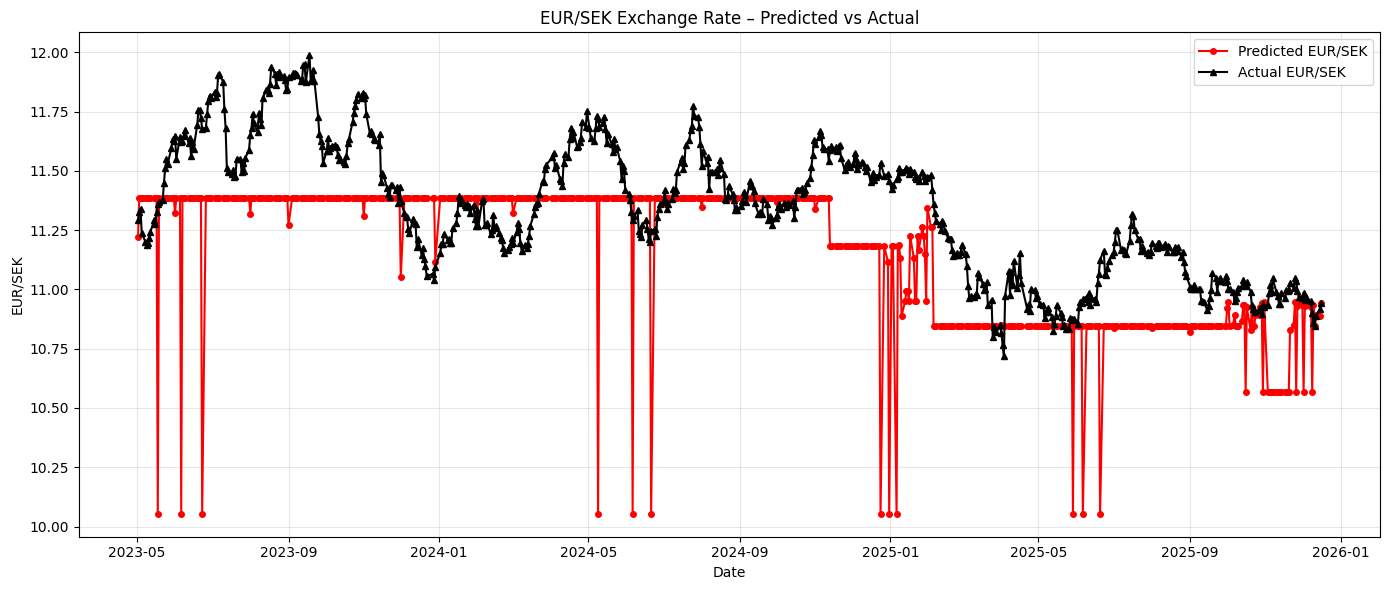

In [ ]:
plot_df = pd.DataFrame({
    "date": pd.to_datetime(X_test["date"]),
    "actual": y_test.iloc[:, 0].values,   # extract target correctly
    "predicted": y_pred
}).sort_values("date")



import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Predicted
plt.plot(
    plot_df["date"],
    plot_df["predicted"],
    color="red",
    marker="o",
    linestyle="-",
    linewidth=1.5,
    markersize=4,
    label="Predicted EUR/SEK"
)

# Actual
plt.plot(
    plot_df["date"],
    plot_df["actual"],
    color="black",
    marker="^",
    linestyle="-",
    linewidth=1.5,
    markersize=4,
    label="Actual EUR/SEK"
)

plt.title("EUR/SEK Exchange Rate – Predicted vs Actual")
plt.xlabel("Date")
plt.ylabel("EUR/SEK")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.savefig(images_dir + "/exchange_rate_predicted_vs_actual_no_lag.png")


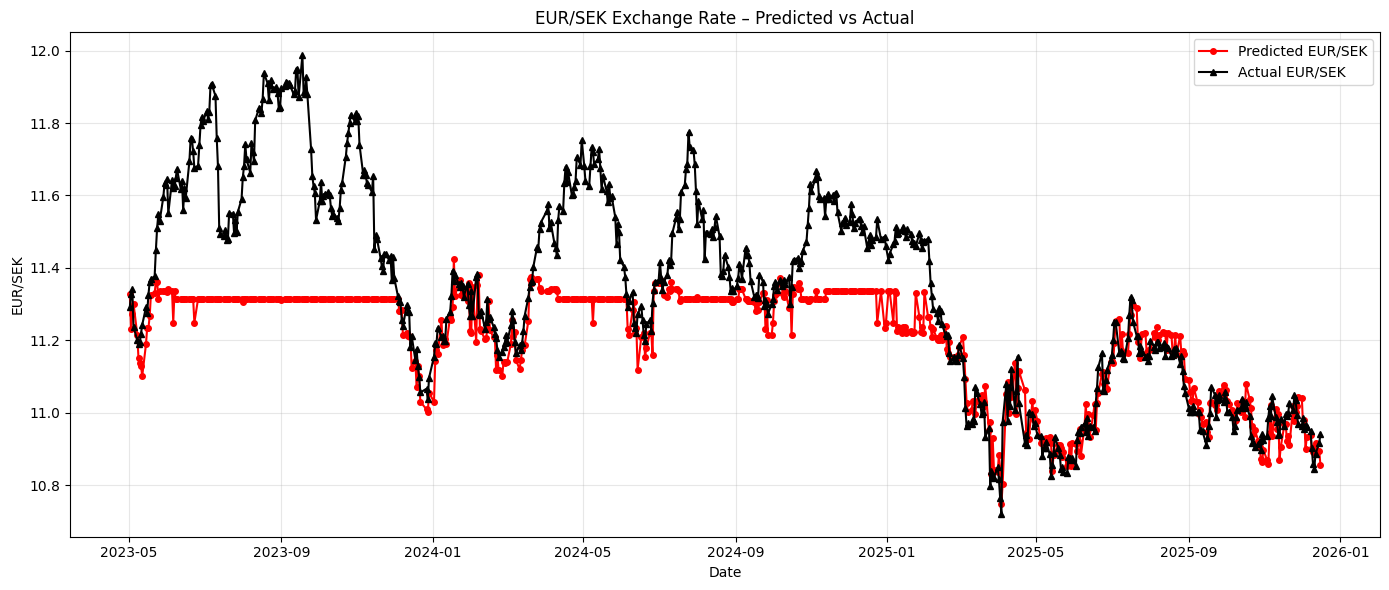

In [ ]:
plot_df = pd.DataFrame({
    "date": pd.to_datetime(X_test["date"]),
    "actual": y_test.iloc[:, 0].values,   # extract target correctly
    "predicted": y_pred_lagged
}).sort_values("date")



import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Predicted
plt.plot(
    plot_df["date"],
    plot_df["predicted"],
    color="red",
    marker="o",
    linestyle="-",
    linewidth=1.5,
    markersize=4,
    label="Predicted EUR/SEK"
)

# Actual
plt.plot(
    plot_df["date"],
    plot_df["actual"],
    color="black",
    marker="^",
    linestyle="-",
    linewidth=1.5,
    markersize=4,
    label="Actual EUR/SEK"
)

plt.title("EUR/SEK Exchange Rate – Predicted vs Actual")
plt.xlabel("Date")
plt.ylabel("EUR/SEK")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.savefig(images_dir + "/exchange_rate_predicted_vs_actual_lag.png")


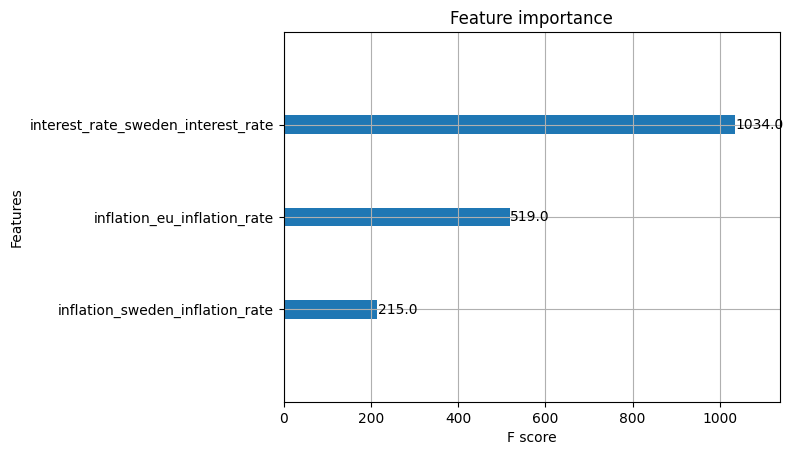

In [174]:
# Plotting feature importances using the plot_importance function from XGBoost
plot_importance(xgb_regressor)
feature_importance_path = images_dir + "/feature_importance.png"
plt.savefig(feature_importance_path)
plt.show()

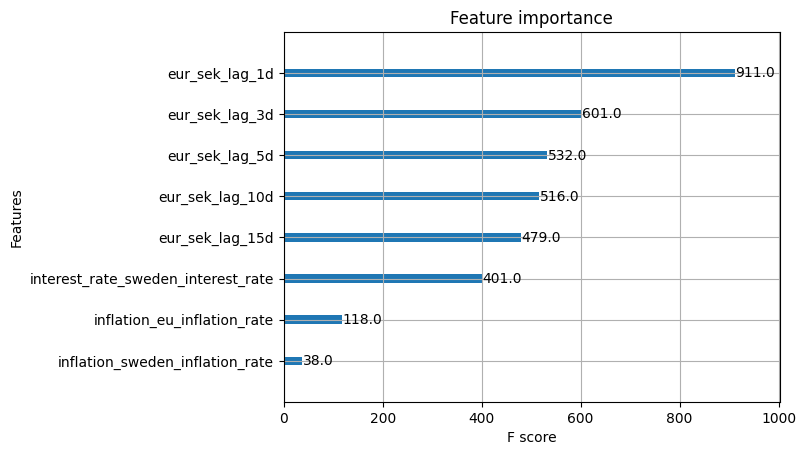

In [175]:
# Plotting feature importances for the model with lagged features
plot_importance(xgb_lagged)
feature_importance_lagged_path = images_dir + "/feature_importance_lagged.png"
plt.savefig(feature_importance_lagged_path)
plt.show()


---

## <span style='color:#ff5f27'>🗄 Model Registry</span>

One of the features in Hopsworks is the model registry. This is where you can store different versions of models and compare their performance. Models from the registry can then be served as API endpoints.

In [176]:
# Saving the XGBoost regressor object as a json file in the model directory
xgb_regressor.save_model(model_dir + "/model.json")

In [177]:
res_dict = { 
        "MSE": str(mse),
        "R squared": str(r2),
    }

In [180]:
mr = project.get_model_registry()

# Creating a Python model in the model registry named 'air_quality_xgboost_model'

aq_model = mr.python.create_model(
    name="xgboost_model", 
    metrics= res_dict,
    feature_view=fv,
    description="EUR/SEK Exchange Rate predictor",
)

# Saving the model artifacts to the 'air_quality_model' directory in the model registry
aq_model.save(model_dir)

  0%|          | 0/6 [00:00<?, ?it/s]

Uploading /Users/yuxinjin/Desktop/KTH/Second-P2/SML/Lab1/exchange_rate_model/model.json: 0.000%|          | 0/…

Uploading /Users/yuxinjin/Desktop/KTH/Second-P2/SML/Lab1/exchange_rate_model/images/feature_importance.png: 0.…

Uploading /Users/yuxinjin/Desktop/KTH/Second-P2/SML/Lab1/exchange_rate_model/images/feature_importance_lagged.…

Uploading /Users/yuxinjin/Desktop/KTH/Second-P2/SML/Lab1/model_schema.json: 0.000%|          | 0/530 elapsed<0…

Model created, explore it at https://c.app.hopsworks.ai:443/p/1286353/models/xgboost_model/1


Model(name: 'xgboost_model', version: 1)

In [181]:
# Save the improved model with lagged features
xgb_lagged.save_model(model_dir + "/model_lagged.json")

# Create metrics dictionary for the improved model
res_dict_lagged = { 
    "MSE": str(mse_lagged),
    "R squared": str(r2_lagged),
}

mr = project.get_model_registry()
# Save improved model to registry
aq_model_lagged = mr.python.create_model(
    name="xgboost_model_lagged", 
    metrics=res_dict_lagged,
    feature_view=fv,  # Note: You may want to create a new feature view with lagged features
    description="EUR/SEK Exchange Rate predictor with lagged features (1, 3, 5, 10, 15 days)",
)

# Save the model artifacts
aq_model_lagged.save(model_dir + "/model_lagged.json")


  0%|          | 0/6 [00:00<?, ?it/s]

Uploading /Users/yuxinjin/Desktop/KTH/Second-P2/SML/Lab1/exchange_rate_model/model_lagged.json: 0.000%|       …

Uploading /Users/yuxinjin/Desktop/KTH/Second-P2/SML/Lab1/model_schema.json: 0.000%|          | 0/530 elapsed<0…

Model created, explore it at https://c.app.hopsworks.ai:443/p/1286353/models/xgboost_model_lagged/1


Model(name: 'xgboost_model_lagged', version: 1)

---
## <span style="color:#ff5f27;">⏭️ **Next:** Part 04: Batch Inference</span>

In the following notebook you will use your model for Batch Inference.
